<a href="https://colab.research.google.com/github/teju917/Machine_learning_lab2/blob/main/RIPPER_FOIL_ALGO_LB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import io
from google.colab import files

!pip install networkx -q

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

print("ORIGINAL DATASET")
print(df.head())

TARGET_ATTR = "class"
TARGET_VAL = "p"

ATTRIBUTES = [
    col for col in df.columns
    if col != TARGET_ATTR
]

DOMAIN = {
    attr: list(df[attr].dropna().unique())
    for attr in ATTRIBUTES
}

print("\nPREPROCESSED DATASET")
print(df.head(10))

print("\nTotal examples:", len(df))
print("Positive examples:", (df[TARGET_ATTR] == TARGET_VAL).sum())
print("Negative examples:", (df[TARGET_ATTR] != TARGET_VAL).sum())


def covers(rule, row):

    return all(
        row[attr] == val
        for attr, val in rule.items()
    )


def evaluate(rule, examples):

    covered = examples[
        examples.apply(
            lambda r: covers(rule, r),
            axis=1
        )
    ]

    pos = (
        covered[TARGET_ATTR] == TARGET_VAL
    ).sum()

    neg = (
        covered[TARGET_ATTR] != TARGET_VAL
    ).sum()

    precision = (
        pos / (pos + neg)
        if (pos + neg) > 0
        else 0
    )

    return pos, neg, precision


def rule_to_str(rule):

    if not rule:
        return "IF (true)"

    conditions = " AND ".join(
        f"{attribute} = {value}"
        for attribute, value in rule.items()
    )

    return f"IF {conditions}"


def learn_one_rule(
        examples,
        beam_width=4,
        max_conditions=None
    ):

    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)

    search_history = []

    beam = [{}]

    depth0_pos, depth0_neg, depth0_prec = evaluate(
        {},
        examples
    )

    search_history.append({
        "depth": 0,
        "candidates": [
            (
                {},
                depth0_pos,
                depth0_neg,
                depth0_prec,
                None
            )
        ],
        "beam": [{}]
    })

    best_rule = {}
    best_pos = depth0_pos
    best_neg = depth0_neg
    best_prec = depth0_prec

    for depth in range(
            1,
            max_conditions + 1
        ):

        candidates = []

        for parent in beam:

            used_attributes = set(parent.keys())

            for attr in ATTRIBUTES:

                if attr in used_attributes:
                    continue

                for value in DOMAIN[attr]:

                    child = dict(parent)

                    child[attr] = value

                    pos, neg, prec = evaluate(
                        child,
                        examples
                    )

                    if pos == 0:
                        continue

                    candidates.append(
                        (
                            child,
                            pos,
                            neg,
                            prec,
                            parent
                        )
                    )

        if not candidates:
            break

        candidates.sort(
            key=lambda c: (
                c[2] == 0,
                c[3],
                c[1]
            ),
            reverse=True
        )

        new_beam = []
        seen = set()

        for child, pos, neg, prec, parent in candidates:

            key = frozenset(
                child.items()
            )

            if key not in seen:

                seen.add(key)

                new_beam.append(child)

            if len(new_beam) >= beam_width:
                break

        beam = new_beam

        search_history.append({
            "depth": depth,
            "candidates": candidates,
            "beam": beam
        })

        pure_candidates = [
            c for c in candidates
            if c[2] == 0
        ]

        if pure_candidates:

            top = pure_candidates[0]

            best_rule = top[0]
            best_pos = top[1]
            best_neg = top[2]
            best_prec = top[3]

            break

        else:

            top = candidates[0]

            if (
                top[2] == 0,
                top[3],
                top[1]
            ) > (
                best_neg == 0,
                best_prec,
                best_pos
            ):

                best_rule = top[0]
                best_pos = top[1]
                best_neg = top[2]
                best_prec = top[3]

    return (
        best_rule,
        best_pos,
        best_neg,
        best_prec,
        search_history
    )


def sequential_covering(beam_width=4):

    working = df.copy()

    rules = []

    round_logs = []

    round_num = 1

    while (
        working[TARGET_ATTR] == TARGET_VAL
    ).sum() > 0:

        rule, pos, neg, prec, history = learn_one_rule(
            working,
            beam_width
        )

        covered_mask = working.apply(
            lambda r: covers(rule, r),
            axis=1
        )

        covered_examples = working[
            covered_mask
        ]

        covered_positive_idx = (
            covered_examples[
                covered_examples[TARGET_ATTR]
                == TARGET_VAL
            ]
            .index
            .tolist()
        )

        print("\nROUND", round_num)

        print(
            "Remaining positive examples:",
            (
                working[TARGET_ATTR]
                == TARGET_VAL
            ).sum()
        )

        print(
            "Learned Rule:",
            rule_to_str(rule),
            "THEN",
            TARGET_ATTR,
            "=",
            TARGET_VAL
        )

        print("Positive covered:", pos)

        print("Negative covered:", neg)

        print(
            f"Precision: {prec:.2f}"
        )

        rules.append(rule)

        round_logs.append({
            "round": round_num,
            "rule": rule,
            "pos_covered": pos,
            "neg_covered": neg,
            "covered_positive_idx": covered_positive_idx,
            "history": history
        })

        working = working.drop(
            index=covered_positive_idx
        )

        round_num += 1

        if pos == 0:
            break

    return rules, round_logs


def plot_search_tree(
        history,
        winning_rule,
        round_num
    ):

    G = nx.DiGraph()

    labels = {}

    node_colors = []

    node_id_of_rule = {}

    def node_id(rule):

        key = frozenset(rule.items())

        if key not in node_id_of_rule:

            node_id_of_rule[key] = (
                f"n{len(node_id_of_rule)}"
            )

        return node_id_of_rule[key]

    root_pos, root_neg, root_prec = (
        history[0]["candidates"][0][1:4]
    )

    root_id = node_id({})

    G.add_node(root_id)

    labels[root_id] = (
        f"(true)\n"
        f"pos={root_pos}\n"
        f"neg={root_neg}"
    )

    winning_key = frozenset(
        winning_rule.items()
    )

    kept_keys = set()

    for level in history:

        for r in level["beam"]:

            kept_keys.add(
                frozenset(r.items())
            )

    kept_keys.add(winning_key)

    for level in history[1:]:

        for child, pos, neg, prec, parent in level["candidates"]:

            key = frozenset(child.items())

            if key not in kept_keys:
                continue

            cid = node_id(child)

            pid = node_id(parent)

            if not G.has_node(cid):

                G.add_node(cid)

                label = " AND ".join(
                    f"{a}={v}"
                    for a, v in child.items()
                )

                labels[cid] = (
                    f"{label}\n"
                    f"pos={pos} neg={neg}"
                )

            G.add_edge(pid, cid)

    for layer, nodes in enumerate(
        nx.bfs_layers(G, root_id)
    ):

        for n in nodes:

            G.nodes[n]["layer"] = layer

    pos_layout = nx.multipartite_layout(
        G,
        subset_key="layer"
    )

    for n in G.nodes():

        key = None

        for k, v in node_id_of_rule.items():

            if v == n:

                key = k

                break

        if key == winning_key:

            node_colors.append("#02C39A")

        elif n == root_id:

            node_colors.append("#028090")

        else:

            node_colors.append("#CFE8E5")

    plt.figure(figsize=(14, 8))

    nx.draw(
        G,
        pos_layout,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        node_size=3500,
        font_size=7,
        font_weight="bold",
        arrows=True
    )

    plt.title(
        f"Round {round_num}: General-to-Specific Search Tree"
    )

    plt.show()


def plot_coverage_bar(round_logs):

    rounds = [
        f"Round {rl['round']}"
        for rl in round_logs
    ]

    covered = [
        rl["pos_covered"]
        for rl in round_logs
    ]

    plt.figure(figsize=(8, 5))

    plt.bar(
        rounds,
        covered
    )

    plt.xlabel("Rounds")

    plt.ylabel(
        "Positive Examples Covered"
    )

    plt.title(
        "Sequential Covering: Examples Covered Per Round"
    )

    plt.show()


def plot_coverage_heatmap(rules):

    n = len(df)

    m = len(rules)

    matrix = [
        [
            1 if covers(
                rule,
                df.loc[i]
            )
            else 0
            for rule in rules
        ]
        for i in range(n)
    ]

    plt.figure(
        figsize=(5 + m, 8)
    )

    plt.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )

    plt.xlabel(
        "Learned Rules"
    )

    plt.ylabel(
        "Training Examples"
    )

    plt.title(
        "Which Rule Covers Which Example?"
    )

    plt.colorbar(
        label="Rule Covers Example"
    )

    plt.show()


print("=" * 70)

print("MUSHROOM CLASSIFICATION DATASET")

print("=" * 70)

print(df.head())

print("\n" + "=" * 70)

print("RUNNING RIPPER/CN2-STYLE SEQUENTIAL COVERING")

print("=" * 70)

rules, round_logs = sequential_covering(
    beam_width=4
)

print("\n" + "=" * 70)

print("FINAL LEARNED RULE SET")

print("=" * 70)

for i, rule in enumerate(
        rules,
        start=1
    ):

    print(f"\nRule {i}:")

    print(
        rule_to_str(rule),
        "THEN",
        TARGET_ATTR,
        "=",
        TARGET_VAL
    )

for rl in round_logs:

    plot_search_tree(
        rl["history"],
        rl["rule"],
        rl["round"]
    )

plot_coverage_bar(
    round_logs
)

plot_coverage_heatmap(
    rules
)

Saving mushrooms.csv to mushrooms.csv
User uploaded file "mushrooms.csv" with length 374003 bytes
ORIGINAL DATASET
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-

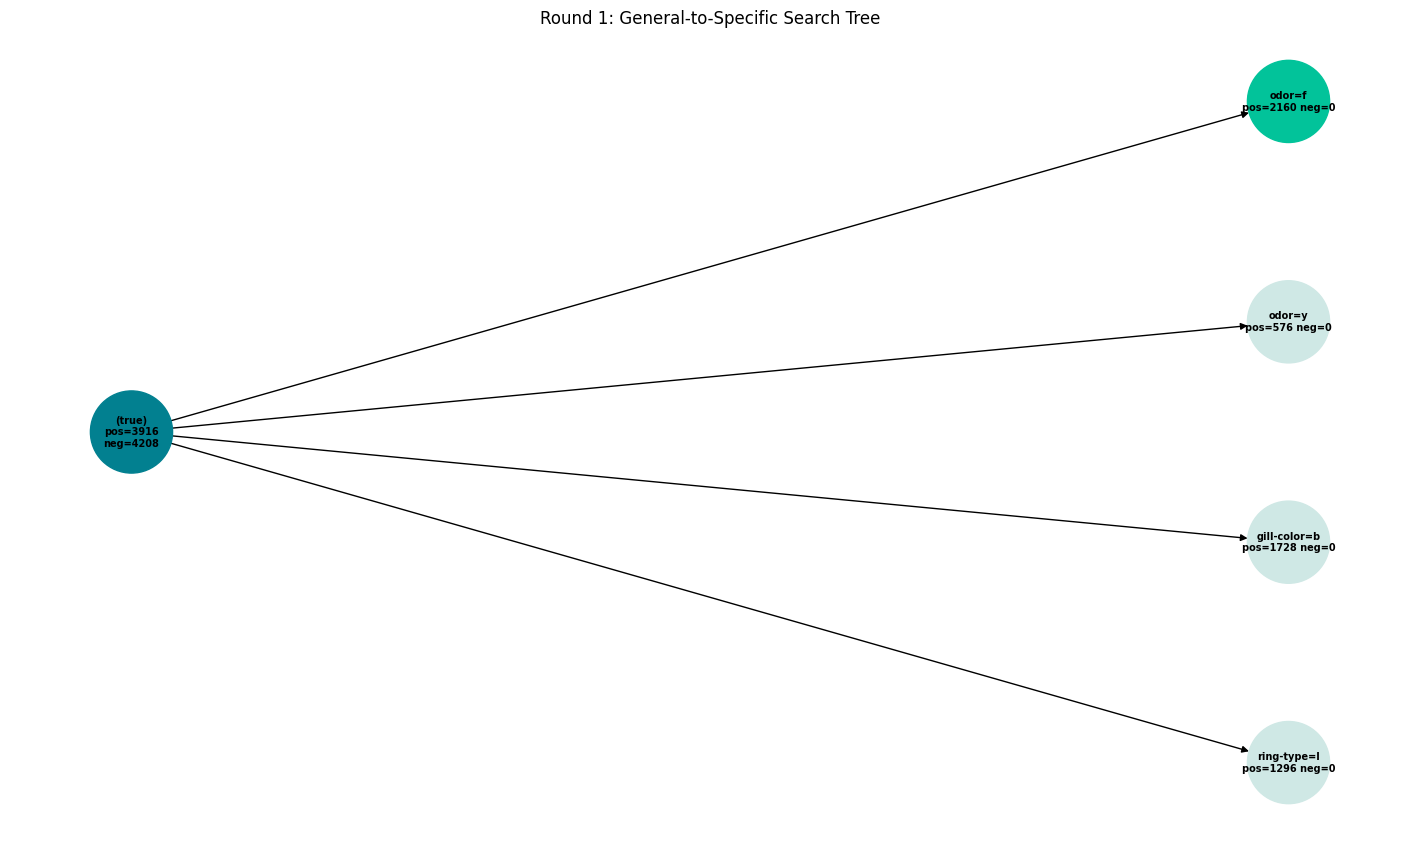

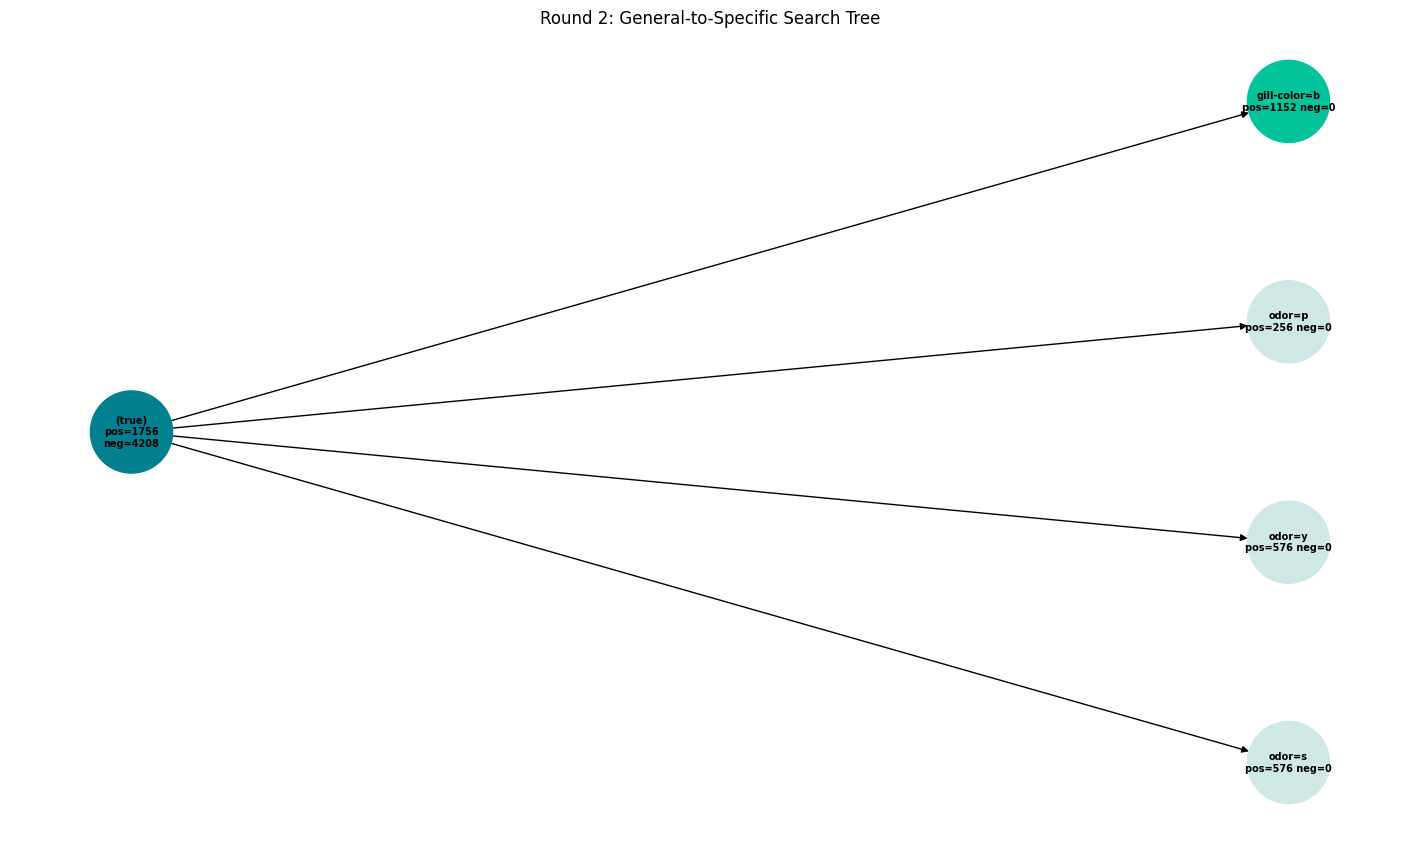

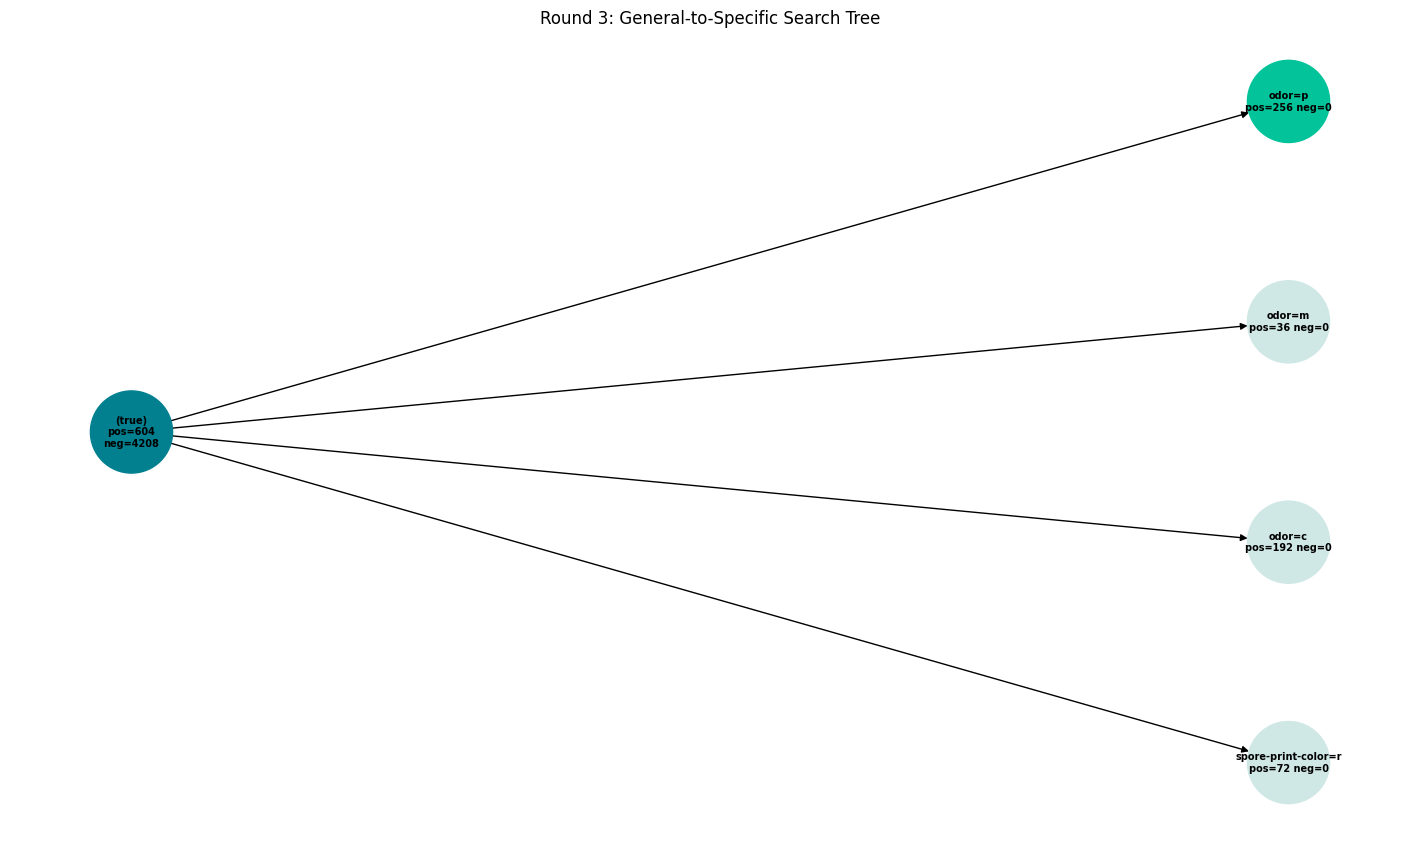

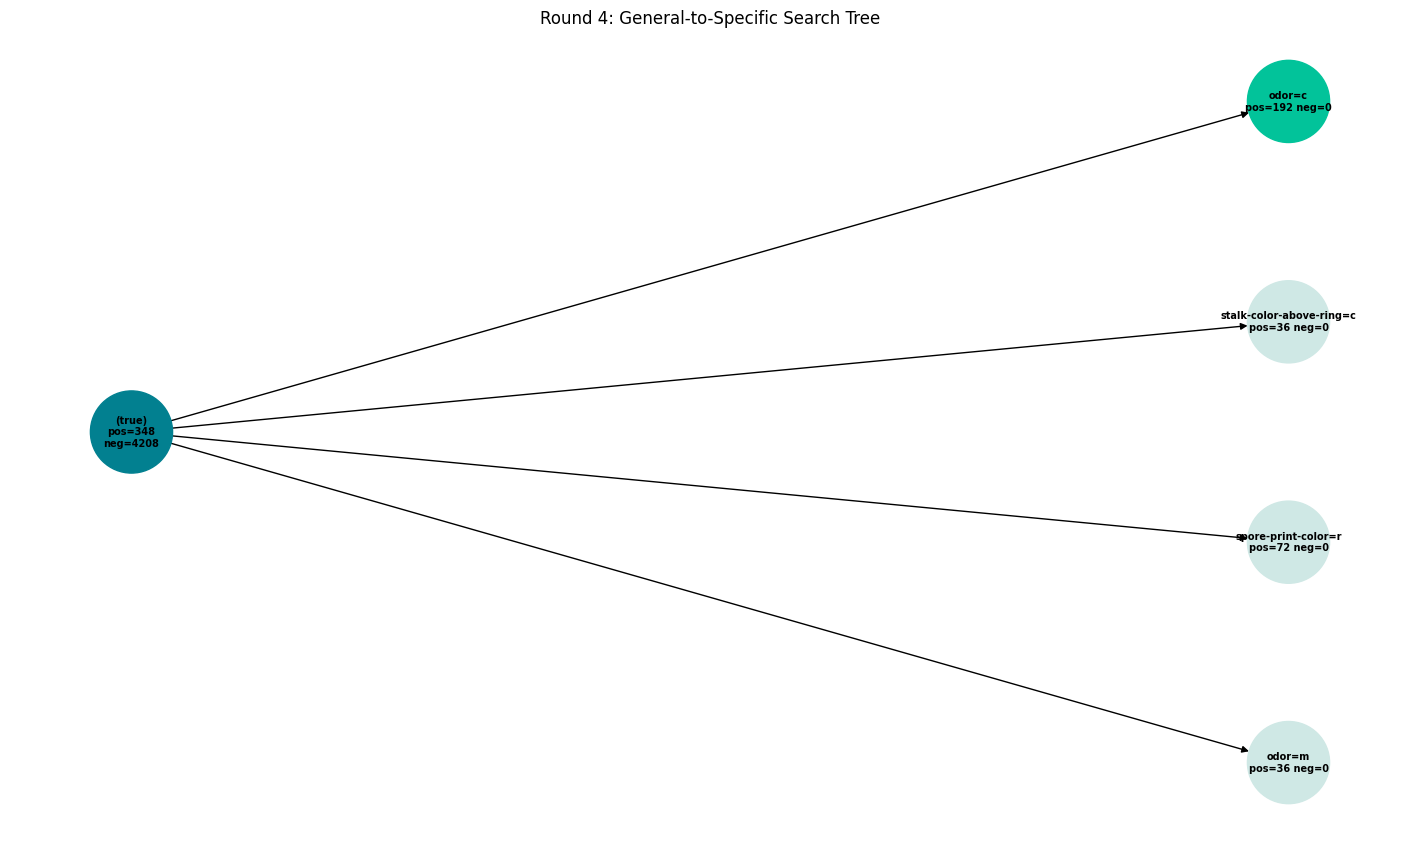

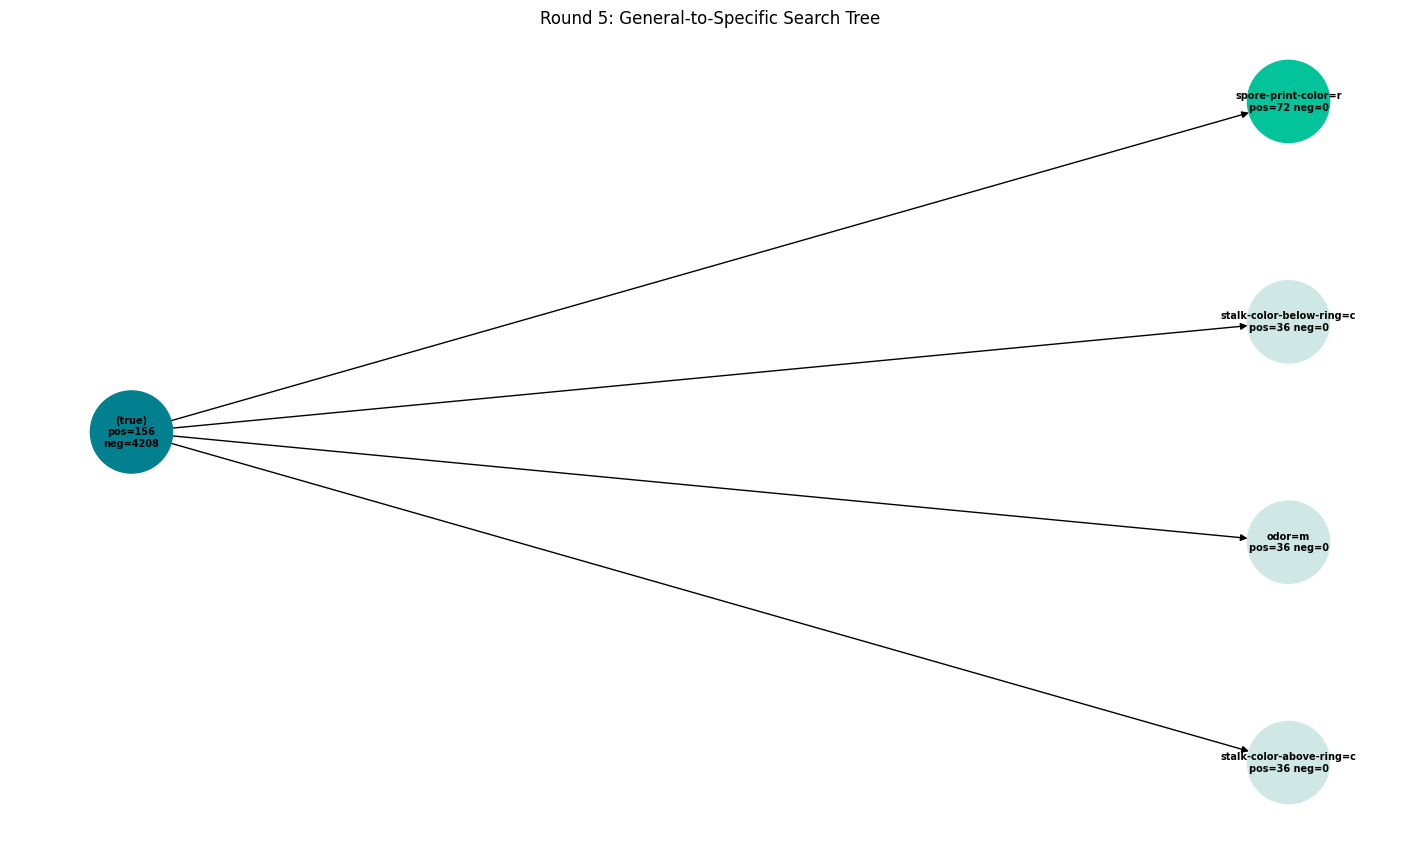

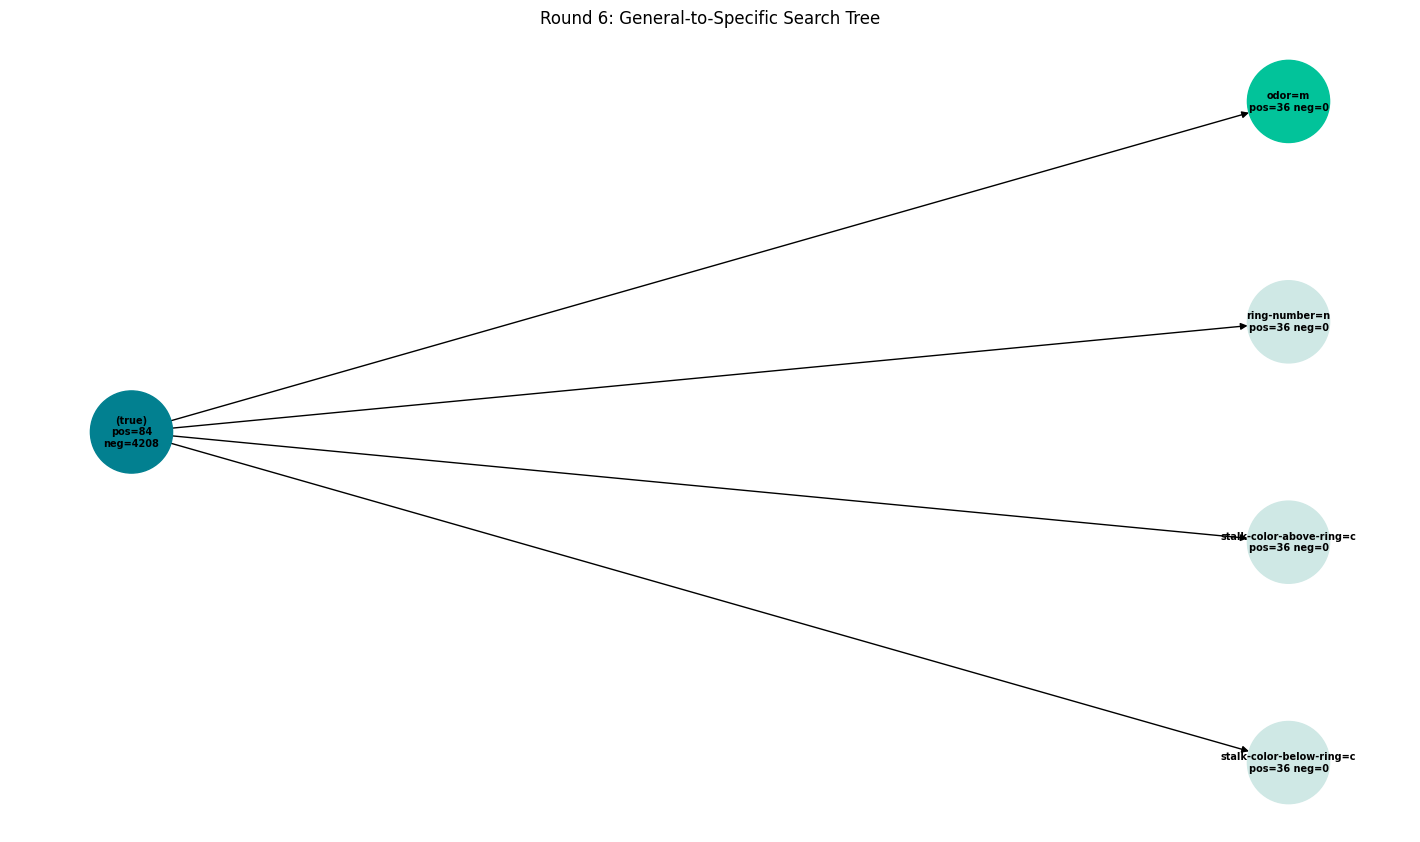

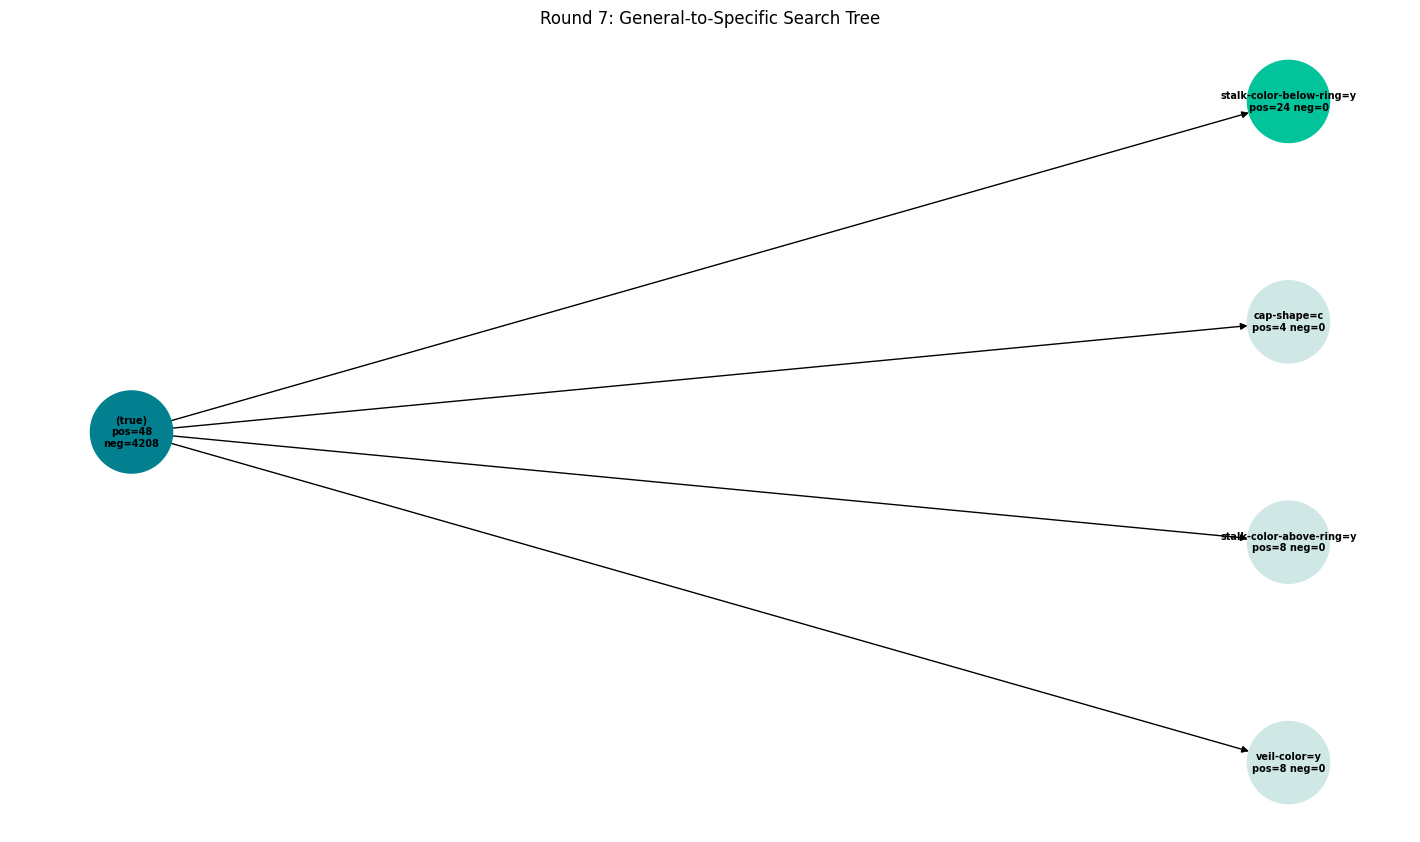

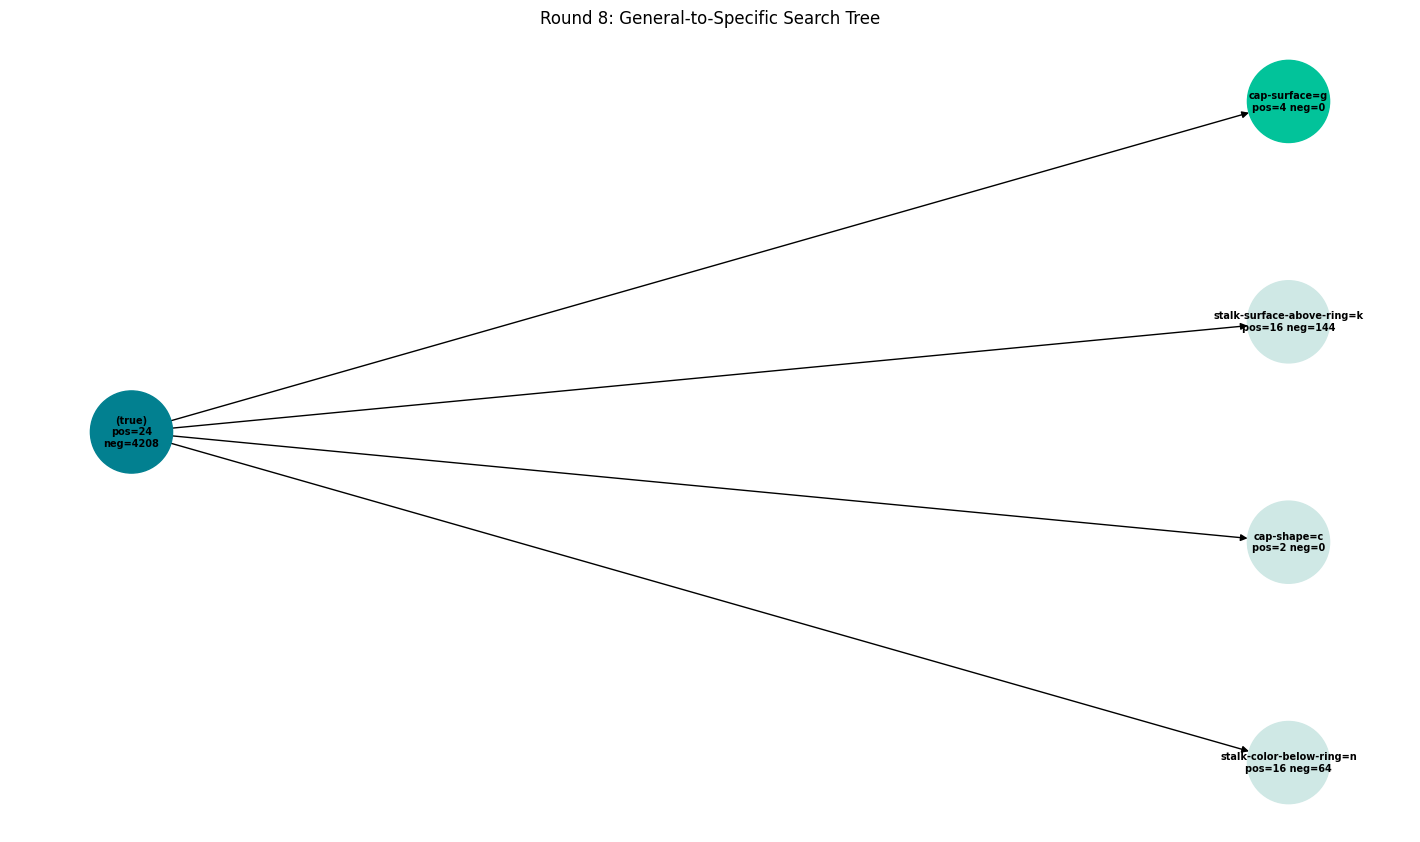

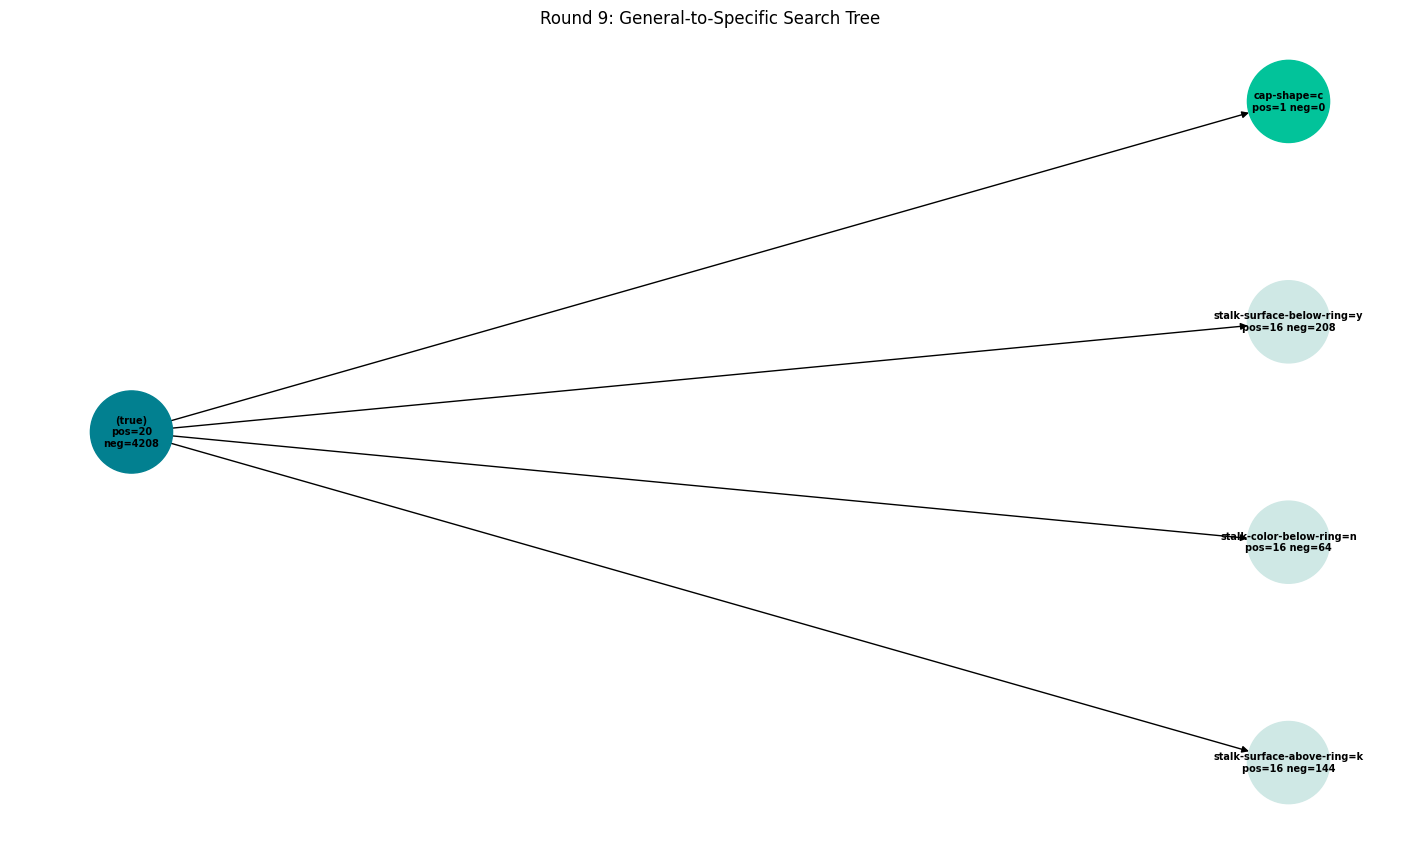

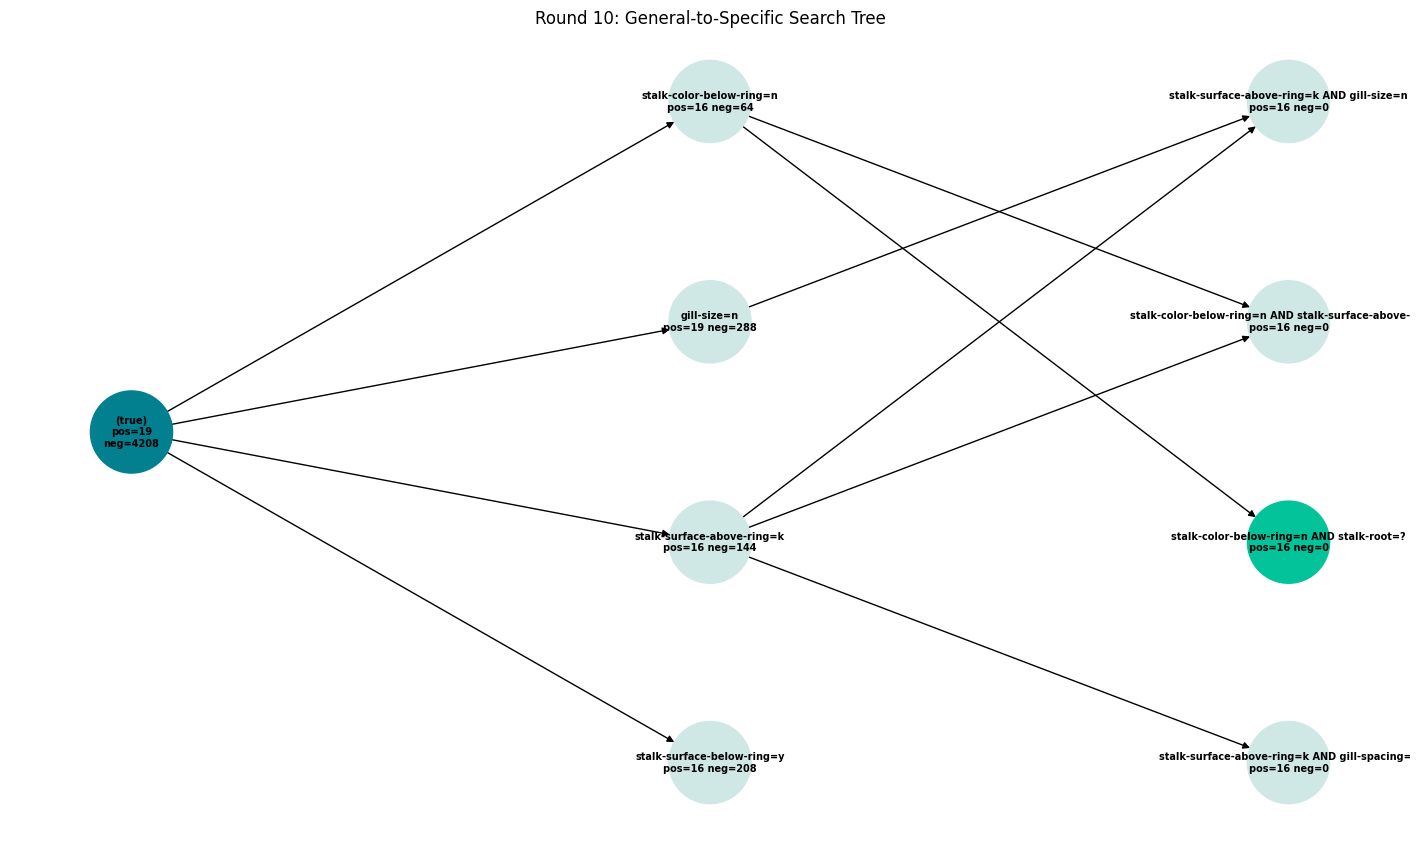

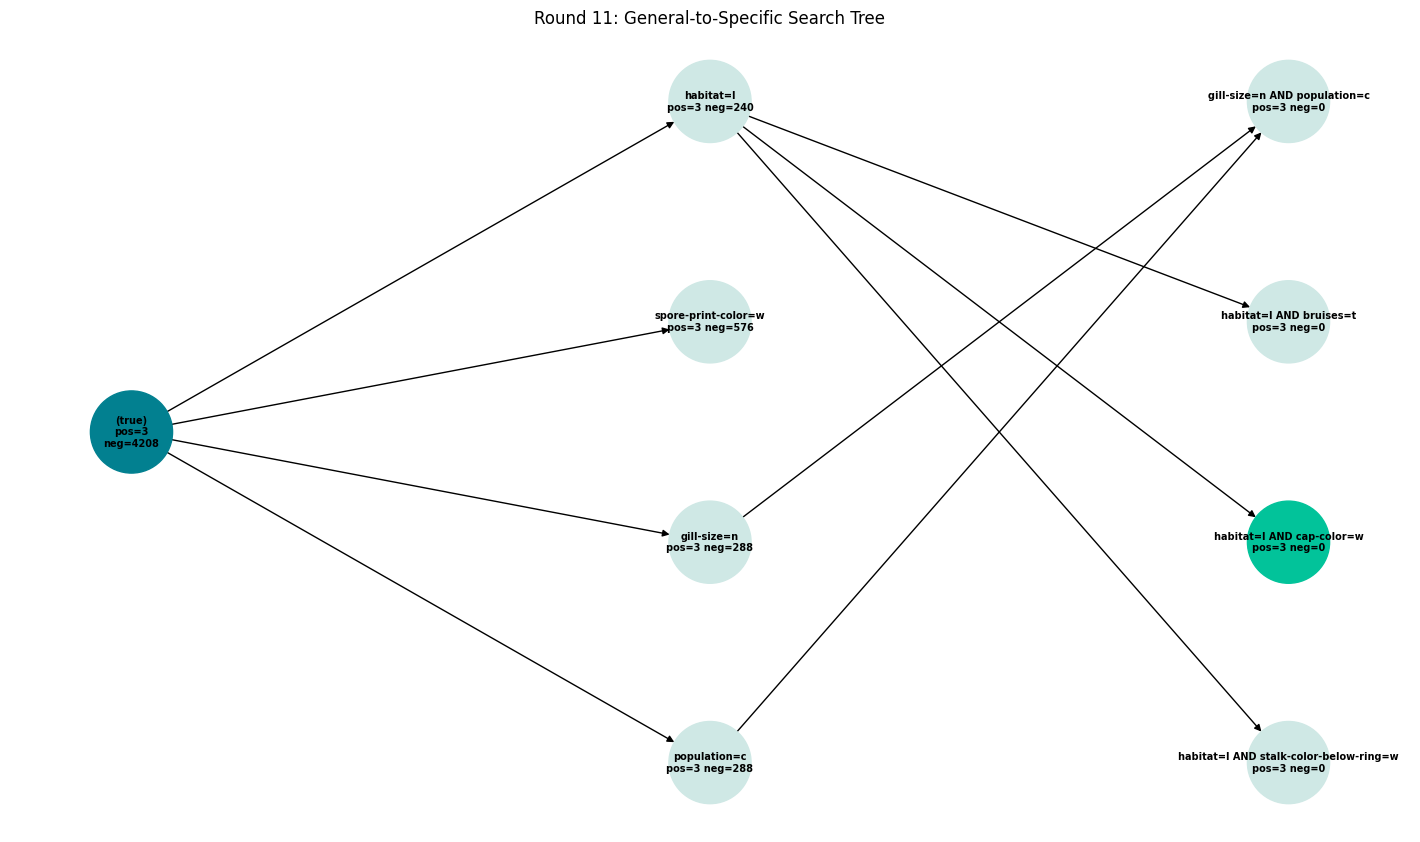

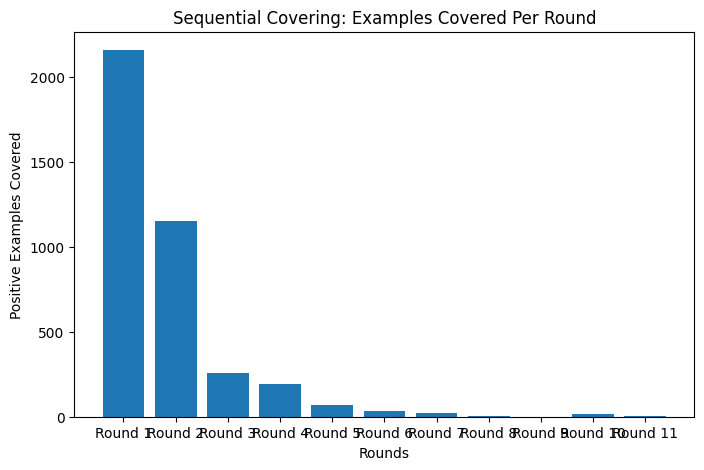

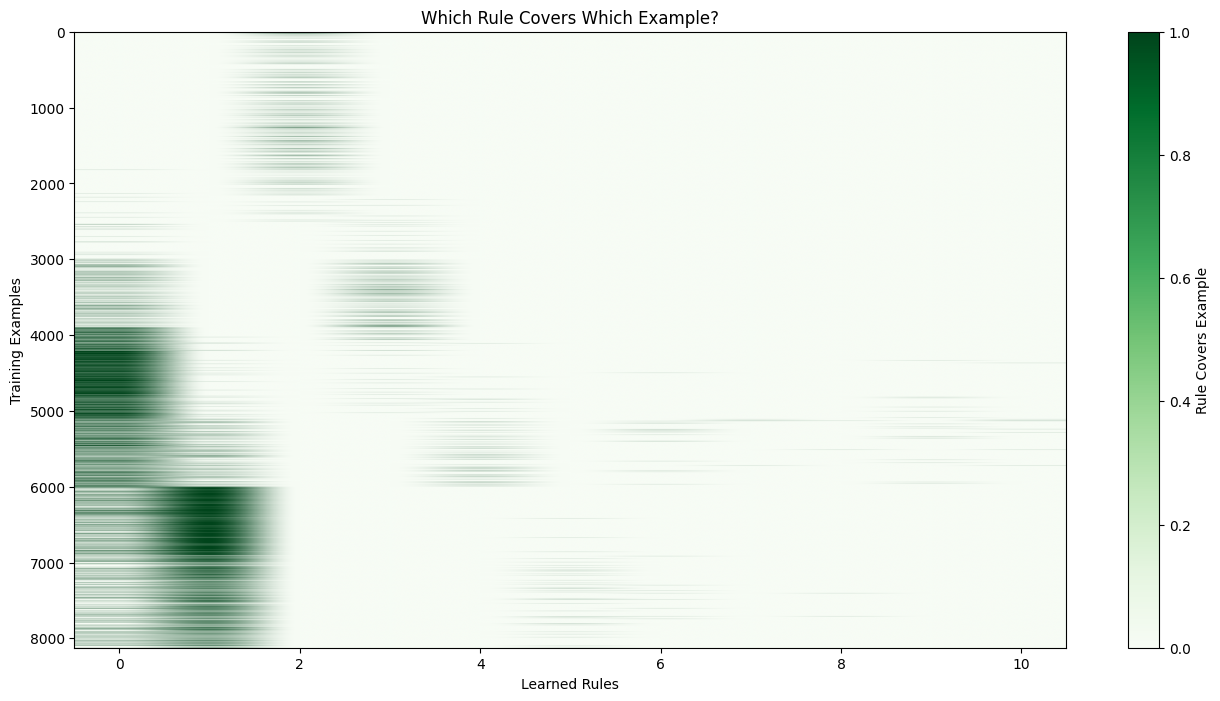